# 📝 Gold Price Prediction in India 

---

### 📌 **Problem Statement**

The objective of this project is to **predict the next day's gold price in India** using historical gold market data. By applying regression models on past features like opening price, high/low values, and trading volume, we aim to forecast the closing price for the next day along with a confidence range.

---

### 🧰 **Tools and Libraries Used**

- **Python**
- **Pandas** – data loading and manipulation  
- **NumPy** – numerical operations  
- **Matplotlib** – data visualization  
- **Scikit-learn (sklearn)** – machine learning (regression models and metrics)  

---

### 📂 **Dataset Overview**

- **File Used**: `gold_data.csv`
- **Total Records**: 1,804 rows  
- **Columns**:

| Column Name | Description                         |
|-------------|-------------------------------------|
| `Date`      | Date of the gold price              |
| `Price`     | Closing price of gold (target)      |
| `Open`      | Opening price of the day            |
| `High`      | Highest price of the day            |
| `Low`       | Lowest price of the day             |
| `Volume`    | Trading volume on that day          |

---

### 🔍 **Modeling Approach**

- A **Linear Regression** model was trained using 80% of the data and tested on the remaining 20%.
- The features used for prediction: `Open`, `High`, `Low`, and `Volume`
- The target: `Price` (closing price of gold)

---

### 📈 **Evaluation Metrics**

The model performance on the test set was measured using:

- **Mean Absolute Error (MAE)**: ~ ₹10.71  
- **Mean Squared Error (MSE)**: ~ ₹152.99  
- **Root Mean Squared Error (RMSE)**: ~ ₹12.37  
- **R² Score**: ~ 0.9814  

---

### 📊 **Final Output & What It Shows**

- The model predicts the **next day’s gold price** using the current day’s market data.
- The predicted value is presented along with a **range (±RMSE)** to account for uncertainty.

**Example Output:**

> 🔮 Tomorrow's predicted gold price: ₹1738.00  
> 🔵 Expected range: ₹1725.64 — ₹1750.37  

---

### 📉 **Charts and Their Meaning**

1. **Actual vs Predicted Gold Prices**
   - Line chart comparing actual closing prices and predicted prices over time.
   - Helps visualize how closely the model tracks real prices.

2. **Prediction Range Chart**
   - Shows the predicted next-day price along with the upper and lower bounds (± RMSE).
   - The shaded region represents the uncertainty zone of the predictions.

---

### ✅ **Conclusion**

- The Linear Regression model performed well with high R² and low error values.
- While it provides a strong baseline, advanced models (like XGBoost or LSTM) can further improve performance for time series forecasting.
- This notebook provides a solid foundation for gold price prediction based on historical pricing data.


In [1]:
#import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_squared_error


In [2]:
# Load the dataset
data = pd.read_csv("gold_data.csv")

# Convert 'Date' column to datetime
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)

# Sort by date
data = data.sort_values('Date')

# Set 'Date' as index (optional but useful for time series)
data.set_index('Date', inplace=True)

# Display first few rows
data.head()


,Price,Open,High,Low,Volume
Date,,,,,
2015-09-29,1127.1,1132.4,1133.6,1123.9,0.25
2015-09-30,1115.5,1127.5,1127.5,1111.3,0.28
2015-10-01,1114.0,1114.9,1118.3,1111.0,0.26
2015-10-02,1136.7,1113.0,1140.7,1105.0,0.47
2015-10-05,1137.7,1138.7,1141.3,1129.8,0.20


In [3]:
# Define features (inputs) and target (output)
X = data[['Open', 'High', 'Low', 'Volume']]
y = data['Price']


In [4]:
# Use 80% of the data for training, 20% for testing (time series split)
split_index = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]


In [5]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [16]:
y_pred = model.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print all metrics neatly
print("📊 Model Evaluation Metrics:")
print(f"🔹 Mean Absolute Error (MAE):     {mae:.2f}")
print(f"🔹 Mean Squared Error (MSE):      {mse:.2f}")
print(f"🔹 Root Mean Squared Error (RMSE):{rmse:.2f}")
print(f"🔹 R² Score:                       {r2:.4f}")

📊 Model Evaluation Metrics:
🔹 Mean Absolute Error (MAE):     10.71
🔹 Mean Squared Error (MSE):      152.97
🔹 Root Mean Squared Error (RMSE):12.37
🔹 R² Score:                       0.9634


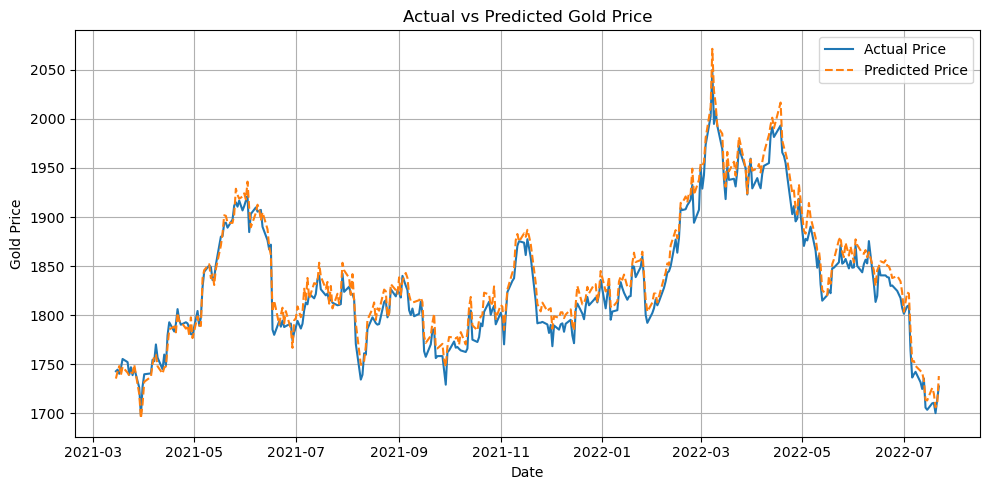

In [7]:
# Plot the actual vs predicted prices
plt.figure(figsize=(10, 5))
plt.plot(y_test.index, y_test, label='Actual Price')
plt.plot(y_test.index, y_pred, label='Predicted Price', linestyle='--')
plt.title('Actual vs Predicted Gold Price')
plt.xlabel('Date')
plt.ylabel('Gold Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
# Shift features up by 1 to use today's data for tomorrow's prediction
future_features = X.shift(1).dropna()

# Predict next-day prices (for all except the first row)
predicted_next_day_price = model.predict(future_features)

# Add predictions and price range to the dataset
data_trimmed = data.iloc[1:].copy()  # remove first row to match shifted predictions
data_trimmed['Predicted_Next_Day_Price'] = predicted_next_day_price
data_trimmed['Price_Range_Lower'] = predicted_next_day_price - rmse
data_trimmed['Price_Range_Upper'] = predicted_next_day_price + rmse

In [14]:
# Use latest day's features to predict tomorrow
last_known_features = X.iloc[-1:].values
next_day_pred = model.predict(last_known_features)[0]

# Calculate prediction range
next_day_lower = next_day_pred - rmse
next_day_upper = next_day_pred + rmse

# Print result
print(f"🔮 Tomorrow's predicted gold price: ₹{next_day_pred:.2f}")
print(f"🔵 Expected range: ₹{next_day_lower:.2f} — ₹{next_day_upper:.2f}")

🔮 Tomorrow's predicted gold price: ₹1738.00
🔵 Expected range: ₹1725.64 — ₹1750.37


C:\Users\Mruna\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


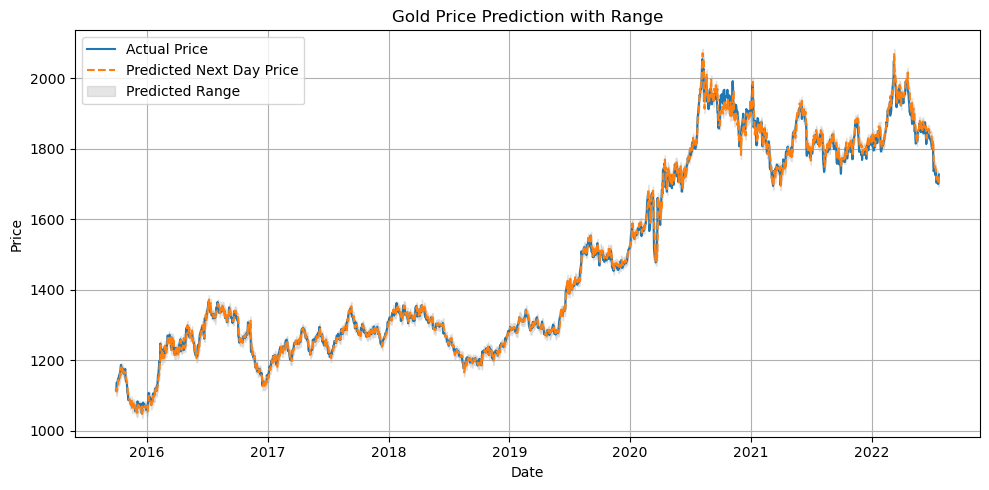

In [13]:
# Save the new dataset
data_trimmed.to_csv("gold_data_with_predictions.csv")

# Plot predicted range for visual check
plt.figure(figsize=(10, 5))
plt.plot(data_trimmed.index, data_trimmed['Price'], label='Actual Price')
plt.plot(data_trimmed.index, data_trimmed['Predicted_Next_Day_Price'], label='Predicted Next Day Price', linestyle='--')
plt.fill_between(data_trimmed.index, data_trimmed['Price_Range_Lower'], data_trimmed['Price_Range_Upper'], color='gray', alpha=0.2, label='Predicted Range')
plt.title('Gold Price Prediction with Range')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()